# India's Equity Market Rank Decline-A Passive Flow & Structural Study

A few weeks ago I came across something that didn't make sense at first glance.

India is the world's 6th largest economy by GDP. South Korea ranks 13th. Taiwan ranks 21st.
Yet in the last week of May 2026, both of them overtook India in equity market capitalisation, 
pushing India from 4th to 7th in global rankings within a matter of days.

18 months ago, India's market cap was 3.5x that of South Korea. That gap is now gone.

The obvious explanation is the AI rally — TSMC, Samsung, SK Hynix have surged on global 
semiconductor demand. But that's the surface story. What I wanted to understand was the 
mechanism underneath: how much of India's capital outflow was actually *forced* — not by 
anyone making a call on India, but purely because index weights shifted and passive funds 
had no choice but to rebalance?

And more importantly, once the AI cycle cools and the rupee stabilises, will India's rank 
recover? Or is there something structural missing from India's index that means the gap persists 
regardless of macro conditions?

That's what this study tries to answer.

## What I'm Testing

- **H1:** Do MSCI EM weight changes *lead* FII outflows, or is it the other way around?
- **H2:** Of India's ~$42B FII outflow in 2025–26, how much was passive/mechanical vs. active?
- **H3:** Is India's underperformance vs Korea/Taiwan explained by the rupee and valuations, 
  or by the fact that India simply has no AI/semiconductor stocks in its index?


## 1. Setup & Imports

Standard libraries for data handling, visualisation, and time series econometrics.
`yfinance` pulls index prices and FX rates directly.
The MSCI weights, FII flows, Nifty P/E, and sector weights are entered manually 
from the sources listed in the README, since none of them have a clean public API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import warnings
import time
import requests

from statsmodels.tsa.stattools import grangercausalitytests, adfuller

warnings.filterwarnings('ignore')

# Visual style, consistent across all plots.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Country color palette used throughout every chart.
COLORS = {
    'India':  '#1a5276',
    'Korea':  '#c0392b',
    'Taiwan': '#27ae60',
    'China':  '#f39c12'
}

# Date range for the full study.
START = '2020-01-01'
END   = '2026-06-01'

print("Initialization done. Libraries and global settings ready.")

Initialization done. Libraries and global settings ready.


## 2. Data Collection

### 2.1 Index Prices & Exchange Rates

Pulling monthly closing prices for three equity indices and their exchange rates against USD.
Exchange rates are needed to convert local returns into USD returns later.
since foreign investors measure everything in dollar terms.

We also pull country ETFs (INDA, EWY, EWT) as a cross-check on relative performance, 
these are USD-denominated so they already reflect both local returns and currency moves.

> **Note:** yfinance data is resampled to month-end to match the frequency 
> of the manually entered MSCI and FII data.

In [2]:
# Price data — loaded from local CSV files

ticker_files = {
    'NIFTY50':    'NIFTY50.csv',
    'KOSPI':      'KOSPI.csv',
    'TAIEX':      'TAIEX.csv',
    'USDINR':     'USDINR.csv',
    'USDKRW':     'USDKRW.csv',
    'USDTWD':     'USDTWD.csv',
    'INDIA_ETF':  'INDIA_ETF.csv',
    'KOREA_ETF':  'KOREA_ETF.csv',
    'TAIWAN_ETF': 'TAIWAN_ETF.csv',
}

price_data = {}
for name, filename in ticker_files.items():
    try:
        df = pd.read_csv(filename)
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date').sort_index()
        df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
        df = df.dropna(subset=['Close'])
        price_data[name] = df['Close']
        print(f"  ✓  {name} — {len(df)} rows")
    except FileNotFoundError:
        print(f"  ✗  {name} — CSV file not found in notebook folder")
    except Exception as e:
        print(f"  ✗  {name} — {e}")

prices_df = pd.DataFrame(price_data)
prices_df.index = pd.to_datetime(prices_df.index)
prices_df = prices_df.resample('ME').last()

print(f"\nPrice data shape: {prices_df.shape}")
print(prices_df.tail(3))


  ✓  NIFTY50 — 78 rows
  ✓  KOSPI — 78 rows
  ✓  TAIEX — 78 rows
  ✓  USDINR — 78 rows
  ✓  USDKRW — 78 rows
  ✓  USDTWD — 78 rows
  ✓  INDIA_ETF — 77 rows
  ✓  KOREA_ETF — 77 rows
  ✓  TAIWAN_ETF — 77 rows

Price data shape: (78, 9)
             NIFTY50    KOSPI     TAIEX   USDINR     USDKRW   USDTWD  \
Date                                                                   
2026-04-30  23997.55  6598.87  38926.63  94.9166  1487.3800  31.6265   
2026-05-31  23547.75  8476.15  44732.94  95.0030  1505.9600  31.4118   
2026-06-30  23214.95  7730.82  43225.54  95.3603  1525.8101  31.5409   

            INDIA_ETF  KOREA_ETF  TAIWAN_ETF  
Date                                          
2026-04-30      49.42     160.76       89.88  
2026-05-31      48.56     205.83      102.78  
2026-06-30        NaN        NaN         NaN  


### 2.2 MSCI EM Country Weights

The MSCI publishes monthly index factsheets as free PDFs.
These contain the country weight table, what percentage of the total MSCI EM index 
each country represents at that point in time.
month
Passive funds tracking MSCI EM must hold each country proportional to its weight.
When India's weight drops from 20% to 11%, every passive fund must sell Indian stocks
and buy Korean/Taiwanese ones, purely mechanical rebalancing, no active decision involved.

In [3]:
msci_weights_raw = {
    # 2020
    '2020-01': {'India': 8.1,  'Korea': 12.4, 'Taiwan': 13.6, 'China': 40.8},
    '2020-06': {'India': 8.6,  'Korea': 11.8, 'Taiwan': 14.2, 'China': 41.3},
    '2020-12': {'India': 9.2,  'Korea': 13.1, 'Taiwan': 15.0, 'China': 39.7},
    # 2021
    '2021-06': {'India': 10.8, 'Korea': 12.8, 'Taiwan': 15.8, 'China': 34.6},
    '2021-12': {'India': 12.5, 'Korea': 12.2, 'Taiwan': 16.1, 'China': 32.1},
    # 2022
    '2022-06': {'India': 13.8, 'Korea': 11.6, 'Taiwan': 15.4, 'China': 30.8},
    '2022-12': {'India': 14.2, 'Korea': 11.2, 'Taiwan': 15.1, 'China': 28.9},
    # 2023
    '2023-06': {'India': 15.0, 'Korea': 11.8, 'Taiwan': 17.2, 'China': 26.4},
    '2023-12': {'India': 16.3, 'Korea': 11.4, 'Taiwan': 18.0, 'China': 25.1},
    # 2024
    '2024-06': {'India': 19.2, 'Korea': 10.5, 'Taiwan': 19.8, 'China': 24.6},
    '2024-12': {'India': 20.0, 'Korea': 10.3, 'Taiwan': 21.0, 'China': 23.2},
    # 2025 — the reversal begins
    '2025-03': {'India': 17.5, 'Korea': 10.97,'Taiwan': 19.4, 'China': 27.1},
    '2025-06': {'India': 16.2, 'Korea': 12.5, 'Taiwan': 21.3, 'China': 25.8},
    '2025-09': {'India': 15.2, 'Korea': 10.97,'Taiwan': 19.4, 'China': 31.2},
    '2025-12': {'India': 13.5, 'Korea': 15.0, 'Taiwan': 22.8, 'China': 24.0},
    # 2026
    '2026-03': {'India': 12.2, 'Korea': 19.0, 'Taiwan': 24.1, 'China': 22.8},
    '2026-05': {'India': 10.87, 'Korea': 23.06, 'Taiwan': 26.41, 'China': 20.36},
}

weights_df = pd.DataFrame(msci_weights_raw).T
weights_df.index = pd.to_datetime(weights_df.index) + pd.offsets.MonthEnd(0)
weights_df = weights_df.sort_index().astype(float)
weights_df = weights_df.resample('ME').interpolate(method='time')

print("MSCI EM country weights — last 6 months:")
print(weights_df.tail(6).round(2))


MSCI EM country weights — last 6 months:
            India  Korea  Taiwan  China
2025-12-31  13.50  15.00   22.80  24.00
2026-01-31  13.05  16.38   23.25  23.59
2026-02-28  12.65  17.62   23.65  23.21
2026-03-31  12.20  19.00   24.10  22.80
2026-04-30  11.55  21.00   25.24  21.60
2026-05-31  10.87  23.06   26.41  20.36


### 2.3 FII Monthly Flow Data, Manual Entry

FII flow data is published monthly by NSDL.
Negative = net outflow (foreigners sold more than they bought).

In [4]:
fii_flows_raw = {
    # 2020 — COVID crash Mar, then strong recovery rally
    '2020-01':  2035,  '2020-02':  -246,  '2020-03': -8363,
    '2020-04': -2091,  '2020-05':  1974,  '2020-06':  3266,
    '2020-07':  1024,  '2020-08':  6429,  '2020-09':   465,
    '2020-10':  2968,  '2020-11':  8145,  '2020-12':  8426,
    # 2021 — strong inflows H1, reversal Oct onwards
    '2021-01':  2629,  '2021-02':  3489,  '2021-03':  1478,
    '2021-04': -1395,  '2021-05':   582,  '2021-06':  2329,
    '2021-07':   329,  '2021-08':  2228,  '2021-09':   140,
    '2021-10': -3760,  '2021-11': -4048,  '2021-12': -1836,
    # 2022 — heavy selling H1 (Fed hikes), partial recovery H2
    '2022-01': -4163,  '2022-02': -4449,  '2022-03': -5144,
    '2022-04': -3077,  '2022-05': -4999,  '2022-06': -6275,
    '2022-07':  -784,  '2022-08':  1830,  '2022-09': -3499,
    '2022-10': -1983,  '2022-11':  4532,  '2022-12':  1454,
    # 2023 — mixed, India MSCI weight climbing to peak
    '2023-01': -3493,  '2023-02':  -642,  '2023-03': -2501,
    '2023-04':   692,  '2023-05':  3372,  '2023-06':  5708,
    '2023-07':  5651,  '2023-08':  1483,  '2023-09': -1788,
    '2023-10': -2906,  '2023-11':  1093,  '2023-12':  8007,
    # 2024 — strong H1/Q3 inflows, massive Oct selloff (-$13.6B)
    # Note: Nov/Dec recovered — markets still not pricing structural gap fully
    '2024-01': -3076,  '2024-02':  -184,  '2024-03':  6676,
    '2024-04':  2597,  '2024-05': -3054,  '2024-06':  3174,
    '2024-07':  3867,  '2024-08':  4293,  '2024-09':  6853,
    '2024-10':-13615,  '2024-11':  4649,  '2024-12':  6982,
    # 2025 — H1 still positive (India inflows!), reversal from Jul
    # Key finding: outflows only started H2 2025 as AI rally went parabolic
    '2025-01':   288,  '2025-02':   529,  '2025-03':   213,
    '2025-04':   574,  '2025-05':  4392,  '2025-06':  5204,
    '2025-07': -5460,  '2025-08': -5373,  '2025-09': -4044,
    '2025-10':  -269,  '2025-11': -2005,  '2025-12': -3935,
    # 2026 — acceleration, Mar 2026 single largest monthly outflow (-$13.1B)
    '2026-01': -4432,  '2026-02':  -710,  '2026-03':-13106,
    '2026-04': -7501,  '2026-05': -5985,
}

fii_df = pd.Series(fii_flows_raw, name='fii_net_usd_mn')
fii_df.index = pd.to_datetime(fii_df.index) + pd.offsets.MonthEnd(0)
fii_df = fii_df.sort_index()

print("FII net flows (USD million) — last 6 months:")
print(fii_df.tail(6))
print(f"\nTotal outflow Jan 2025 → May 2026: ${fii_df['2025':].sum():,.0f}M")
print(f"Total observations: {len(fii_df)} months")
print(f"\nH1 2025 (Jan-Jun): ${fii_df['2025-01':'2025-06'].sum():,.0f}M")
print(f"H2 2025 (Jul-Dec): ${fii_df['2025-07':'2025-12'].sum():,.0f}M")
print(f"2026 (Jan-May):    ${fii_df['2026':].sum():,.0f}M")

FII net flows (USD million) — last 6 months:
2025-12-31    -3935
2026-01-31    -4432
2026-02-28     -710
2026-03-31   -13106
2026-04-30    -7501
2026-05-31    -5985
Name: fii_net_usd_mn, dtype: int64

Total outflow Jan 2025 → May 2026: $-41,620M
Total observations: 77 months

H1 2025 (Jan-Jun): $11,200M
H2 2025 (Jul-Dec): $-21,086M
2026 (Jan-May):    $-31,734M


### 2.4 Nifty P/E Ratio & MSCI Sector Weights
The key structural gap: India has ~0% in semiconductors while Korea and Taiwan 
have 40–68% in Information Technology (almost entirely semiconductors).

**MSCI EM sector returns** — the return each global EM sector delivered over our study period.
Same return vector applied to all three countries, only weights differ.

In [5]:
nifty_pe_raw = {
    # 2024 — Source: Nifty 50 monthly P/E data
    '2024-01': 22.9, '2024-02': 22.7, '2024-03': 22.9,
    '2024-04': 22.8, '2024-05': 21.6, '2024-06': 22.2,
    '2024-07': 23.2, '2024-08': 22.9, '2024-09': 23.7,
    '2024-10': 23.2, '2024-11': 22.1, '2024-12': 22.3,
    # 2025
    '2025-01': 21.4, '2025-02': 20.6, '2025-03': 20.3,
    '2025-04': 21.3, '2025-05': 22.2, '2025-06': 22.5,
    '2025-07': 22.5, '2025-08': 21.7, '2025-09': 21.9,
    '2025-10': 22.5, '2025-11': 22.5, '2025-12': 22.6,
    # 2026
    '2026-01': 22.3, '2026-02': 22.3, '2026-03': 20.6,
    '2026-04': 20.9, '2026-05': 20.6,
}
pe_series = pd.Series(nifty_pe_raw, name='nifty_pe')
pe_series.index = pd.to_datetime(pe_series.index) + pd.offsets.MonthEnd(0)
sector_weights = {
    'India': {
    'IT Services':            7.49,   # real — MSCI India factsheet May 2026
    'IT Semiconductors':       0.0,   # real — zero, confirmed
    'IT AI / Foundry':         0.0,   # real — zero, confirmed
    'Financials':             28.47,  # real
    'Consumer Discretionary': 12.17,  # real
    'Industrials':            11.53,  # real
    'Materials':               9.16,  # real
    'Energy':                  8.61,  # real
    'Health Care':             6.31,  # real
    'Consumer Staples':        6.00,  # real
    'Communication Services':  4.71,  # real
    'Utilities':               4.19,  # real
    'Real Estate':             1.35,  # real
},

    'Korea': {
    'IT Services':             4.0,   # minor
    'IT Semiconductors':      37.0,   # Samsung Electronics + SK Hynix
    'IT AI / Foundry':         2.0,   # Samsung Foundry
    'Financials':             13.9,
    'Consumer Discretionary': 10.6,
    'Industrials':             8.9,
    'Communication Services':  7.1,
    'Materials':               6.7,
    'Health Care':             4.1,
    'Consumer Staples':        3.2,
    'Energy':                  1.5,
    'Utilities':               0.6,
    'Real Estate':             0.4,
},
    'Taiwan': {
        'IT Services':             1.2,  # negligible
        'IT Semiconductors':      0.0,   # MediaTek, ASE Group, other chip cos
        'IT AI / Foundry':        54.8,  # TSMC alone
        'Financials':             12.1,
        'Consumer Discretionary':  5.8,
        'Industrials':             4.9,
        'Materials':               3.8,
        'Communication Services':  2.9,
        'Consumer Staples':        1.2,
        'Health Care':             0.7,
        'Energy':                  0.4,
        'Utilities':               0.0,
        'Real Estate':             0.0,
    }
}

sector_returns = {
    'IT Services':            -42.4,   # TCS/Infosys — moderate outsourcing growth
    'IT Semiconductors':    72.4,   # Samsung + SK Hynix — AI server memory demand
    'IT AI / Foundry':        100.0,   # TSMC — sole manufacturer of Nvidia/Apple/AMD chips
    'Financials':              9.8,
    'Energy':                  3.1,
    'Consumer Discretionary': 12.4,
    'Consumer Staples':        5.6,
    'Health Care':             7.2,
    'Industrials':            14.8,
    'Materials':               4.2,
    'Communication Services': 11.3,
    'Utilities':               3.8,
    'Real Estate':            -1.2,
}

print("Nifty 50 P/E — Jan 2024 peak vs May 2026:")
print(f"  Jan 2024: {pe_series['2024-01-31']:.1f}x")
print(f"  May 2026: {pe_series['2026-05-31']:.1f}x")
print(f"  Change:   {((pe_series['2026-05-31'] / pe_series['2024-01-31']) - 1)*100:.1f}%")

print("\nIT exposure by country:")
for country in sector_weights:
    svc  = sector_weights[country]['IT Services']
    semi = sector_weights[country]['IT Semiconductors']
    ai   = sector_weights[country]['IT AI / Foundry']
    print(f"  {country:<8}  Services {svc:.1f}%  |  Semiconductors {semi:.1f}%"
          f"  |  AI/Foundry {ai:.1f}%  |  Total IT {svc+semi+ai:.1f}%")

print("\nAll manual data ready.")


Nifty 50 P/E — Jan 2024 peak vs May 2026:
  Jan 2024: 22.9x
  May 2026: 20.6x
  Change:   -10.0%

IT exposure by country:
  India     Services 7.5%  |  Semiconductors 0.0%  |  AI/Foundry 0.0%  |  Total IT 7.5%
  Korea     Services 4.0%  |  Semiconductors 37.0%  |  AI/Foundry 2.0%  |  Total IT 43.0%
  Taiwan    Services 1.2%  |  Semiconductors 0.0%  |  AI/Foundry 54.8%  |  Total IT 56.0%

All manual data ready.


## 3. Passive Flow Estimation & Granger Causality

### 3.1 How Much of India's $45B Outflow Was Mechanical?

When MSCI reduces India's weight, every passive fund must sell Indian stocks proportionally.

> **Estimated Passive Outflow = Δ Weight (%) × Total Passive AUM tracking MSCI EM**

We use $300B as a conservative AUM estimate. The residual between actual FII outflow 
and the passive estimate is the active/discretionary selling component.

### 3.2 Which Came First, Weight Drop or Outflow?

The Granger causality test checks whether past values of X help predict Y,
beyond what Y's own past already explains.

- Weight changes lead flows → passive mechanics are the primary driver (H1 supported)
- Flows lead weight changes → active investors sold first, weight followed as market cap fell
- Bidirectional → feedback loop

In [6]:
# Align both series on month-end index
weights_monthly = weights_df['India'].copy()
weights_monthly.index = weights_monthly.index + pd.offsets.MonthEnd(0)

fii_aligned = fii_df.copy()
fii_aligned.index = fii_aligned.index + pd.offsets.MonthEnd(0)

common_idx   = weights_monthly.index.intersection(fii_aligned.index)
india_weight = weights_monthly.loc[common_idx]
fii_flow     = fii_aligned.loc[common_idx]

# Monthly weight change — this is what triggers passive rebalancing
weight_change = india_weight.diff().dropna()
fii_flow      = fii_flow.loc[weight_change.index]

print(f"Aligned data: {len(common_idx)} months")
print(f"Weight change range: {weight_change.min():.2f}% to {weight_change.max():.2f}%")

# Passive flow estimation
PASSIVE_AUM_USD_BN = 300

passive_flow = (weight_change / 100) * PASSIVE_AUM_USD_BN * 1000

outflow_mask  = fii_flow.index >= '2025-01-01'
total_fii     = fii_flow[outflow_mask].sum()
total_passive = passive_flow[outflow_mask].sum()
total_active  = total_fii - total_passive

print(f"\n Passive Flow Decomposition (Jan 2025 → May 2026) ")
print(f"Total actual FII outflow:      ${total_fii:,.0f}M")
print(f"Estimated passive outflow:     ${total_passive:,.0f}M")
print(f"Implied active outflow:        ${total_active:,.0f}M")
print(f"\nPassive share: {abs(total_passive/total_fii)*100:.1f}%")
print(f"Active share:  {abs(total_active/total_fii)*100:.1f}%")

# Stationarity check 
print(f"\n ADF Stationarity Tests ")
for name, series in [('MSCI Weight Change', weight_change), ('FII Flow', fii_flow)]:
    clean = series.dropna()
    if len(clean) < 5:
        print(f"  {name}: not enough data points")
        continue
    stat, p, *_ = adfuller(clean)
    result = 'STATIONARY ✓' if p < 0.05 else 'NON-STATIONARY ✗'
    print(f"  {name}: p = {p:.4f} → {result}")

# Granger causality
granger_df = pd.DataFrame({
    'weight_change': weight_change,
    'fii_flow':      fii_flow
}).dropna()

print(f"\nGranger input: {granger_df.shape[0]} observations")

MAX_LAGS = 3

print(f"\n Granger Causality Results")
print("H0: X does NOT Granger-cause Y  (reject if p < 0.05)\n")

print("Test 1: Does WEIGHT CHANGE → predict → FII OUTFLOW?")
r1 = grangercausalitytests(granger_df[['fii_flow', 'weight_change']],
                            maxlag=MAX_LAGS, verbose=False)
for lag in range(1, MAX_LAGS + 1):
    p = r1[lag][0]['ssr_ftest'][1]
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f"  Lag {lag}: p = {p:.4f}  {sig}")

print("\nTest 2: Does FII OUTFLOW → predict → WEIGHT CHANGE?")
r2 = grangercausalitytests(granger_df[['weight_change', 'fii_flow']],
                            maxlag=MAX_LAGS, verbose=False)
for lag in range(1, MAX_LAGS + 1):
    p = r2[lag][0]['ssr_ftest'][1]
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f"  Lag {lag}: p = {p:.4f}  {sig}")

Aligned data: 77 months
Weight change range: -0.86% to 0.49%

 Passive Flow Decomposition (Jan 2025 → May 2026) 
Total actual FII outflow:      $-41,620M
Estimated passive outflow:     $-27,390M
Implied active outflow:        $-14,230M

Passive share: 65.8%
Active share:  34.2%

 ADF Stationarity Tests 
  MSCI Weight Change: p = 0.6271 → NON-STATIONARY ✗
  FII Flow: p = 0.0710 → NON-STATIONARY ✗

Granger input: 76 observations

 Granger Causality Results
H0: X does NOT Granger-cause Y  (reject if p < 0.05)

Test 1: Does WEIGHT CHANGE → predict → FII OUTFLOW?
  Lag 1: p = 0.1360  ✗ not significant
  Lag 2: p = 0.2951  ✗ not significant
  Lag 3: p = 0.5310  ✗ not significant

Test 2: Does FII OUTFLOW → predict → WEIGHT CHANGE?
  Lag 1: p = 0.6323  ✗ not significant
  Lag 2: p = 0.8429  ✗ not significant
  Lag 3: p = 0.0148  ✓ significant


## 4. Visualisation

Three panels showing:
1. India's MSCI EM weight declining over time
2. Monthly FII flows (actual) vs estimated passive outflow
3. Cumulative flows - separating passive from active

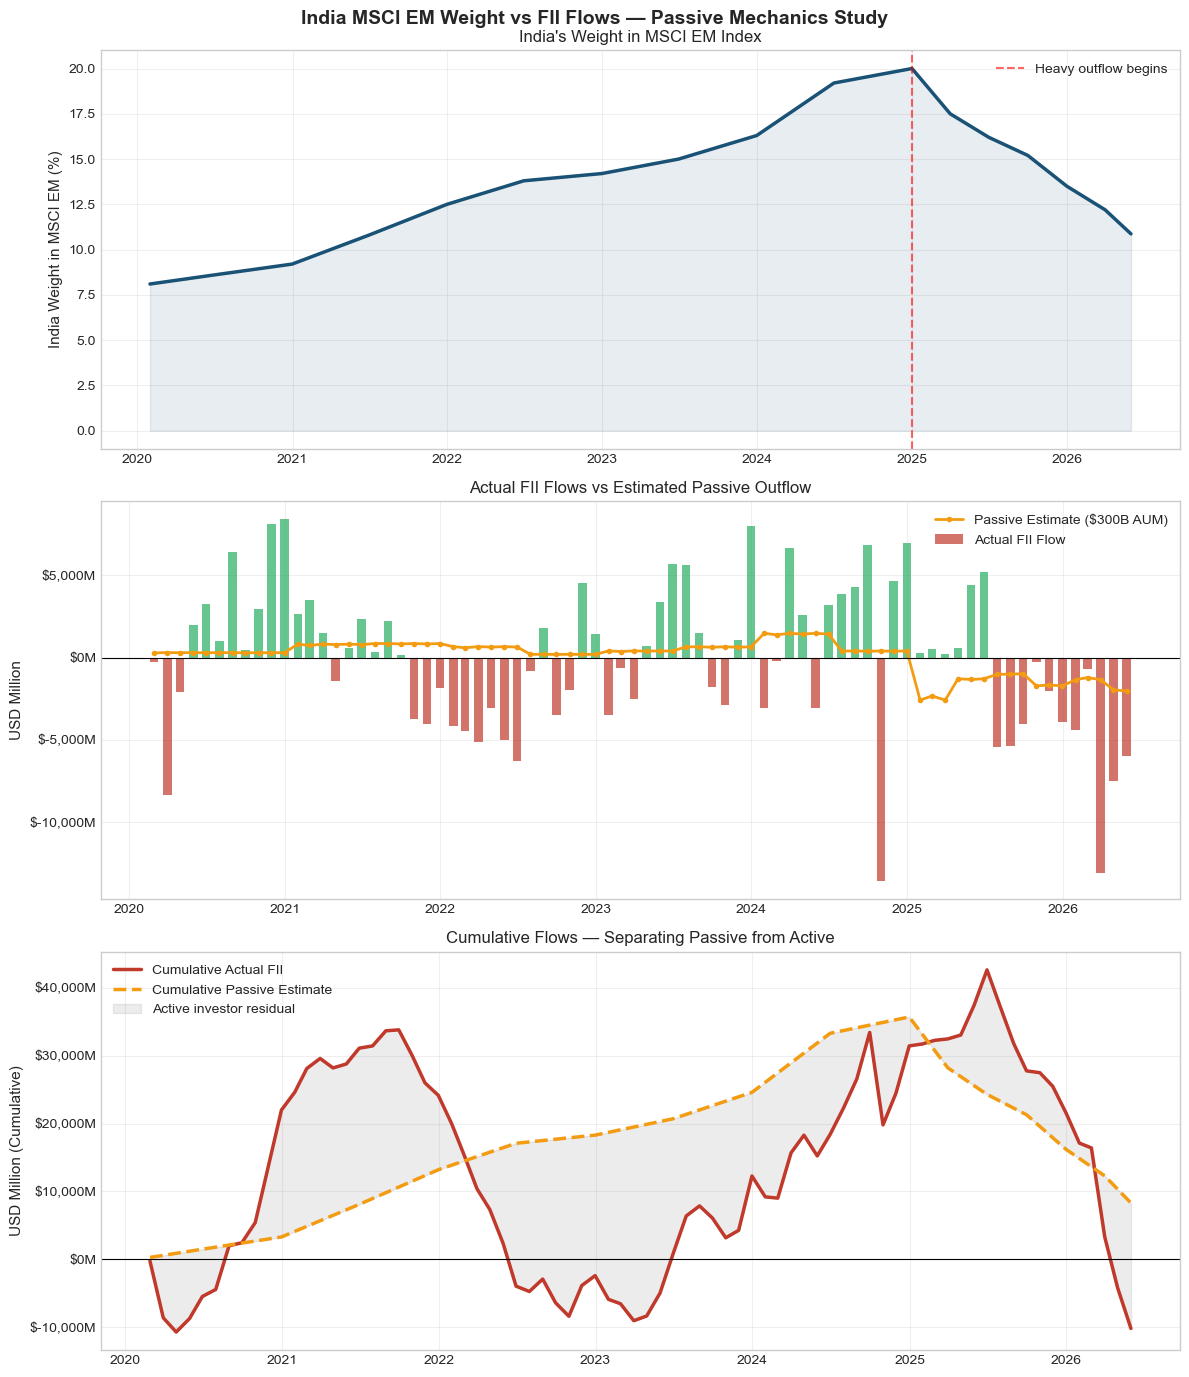

Chart saved → phase2_passive_flow.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle("India MSCI EM Weight vs FII Flows — Passive Mechanics Study",
             fontsize=14, fontweight='bold', y=0.98)

# Panel 1: India MSCI EM weight over time
ax1 = axes[0]
ax1.plot(weights_df.index, weights_df['India'],
         color=COLORS['India'], linewidth=2.5)
ax1.fill_between(weights_df.index, weights_df['India'],
                 alpha=0.1, color=COLORS['India'])
ax1.axvline(pd.Timestamp('2025-01-01'), color='red',
            linestyle='--', alpha=0.6, label='Heavy outflow begins')
ax1.set_ylabel("India Weight in MSCI EM (%)", fontsize=11)
ax1.set_title("India's Weight in MSCI EM Index", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Actual FII flows vs passive estimate
ax2 = axes[1]
bar_colors = [COLORS['Korea'] if v < 0 else '#27ae60' for v in fii_flow.values]
ax2.bar(fii_flow.index, fii_flow.values, width=20,
        color=bar_colors, alpha=0.7, label='Actual FII Flow')
ax2.plot(passive_flow.index, passive_flow.values,
         color='#f39c12', linewidth=2, marker='o', markersize=3,
         label=f'Passive Estimate (${PASSIVE_AUM_USD_BN}B AUM)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel("USD Million", fontsize=11)
ax2.set_title("Actual FII Flows vs Estimated Passive Outflow", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

# Panel 3: Cumulative flows
ax3 = axes[2]
cum_fii     = fii_flow.cumsum()
cum_passive = passive_flow.cumsum()
ax3.plot(cum_fii.index, cum_fii.values,
         color=COLORS['Korea'], linewidth=2.5, label='Cumulative Actual FII')
ax3.plot(cum_passive.index, cum_passive.values,
         color='#f39c12', linewidth=2.5, linestyle='--',
         label='Cumulative Passive Estimate')
ax3.fill_between(cum_fii.index, cum_fii.values, cum_passive.values,
                 alpha=0.15, color='gray', label='Active investor residual')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel("USD Million (Cumulative)", fontsize=11)
ax3.set_title("Cumulative Flows — Separating Passive from Active", fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

plt.tight_layout()
plt.savefig('phase2_passive_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved → phase2_passive_flow.png")

## 5. Currency & Valuation Decomposition

India's market cap fell in USD terms relative to Korea and Taiwan.
We decompose that total gap into three buckets:

**Bucket 1 - Currency effect**
How much of India's USD underperformance is just rupee depreciation?
Formula: USD return = (1 + local return) × (1 + FX return) − 1
The FX component is directly isolatable.

**Bucket 2 - Valuation re-rating**
Did Indian stocks get cheaper on a P/E basis independent of earnings?
If P/E compressed while earnings held up, that's a sentiment-driven drag — potentially reversible.
Formula: Total return = EPS growth component × P/E change component

**Bucket 3 - Structural residual**
Whatever gap remains after stripping out currency and valuation = structural.

> Reversibility test:
> - Currency effect → reversible if RBI stabilises INR
> - Valuation re-rating → partially reversible as sentiment normalises
> - Structural → persistent until India builds AI/semiconductor index exposure

In [8]:
def monthly_ret(series):
    return series.pct_change().dropna()

nifty_local  = monthly_ret(prices_df['NIFTY50'])
kospi_local  = monthly_ret(prices_df['KOSPI'])
taiex_local  = monthly_ret(prices_df['TAIEX'])

# FX return from foreign investor perspective
# INR=X is INR per USD — if rupee weakens, more INR per USD
# Foreign investor return on INR = return on (1/USDINR)
fx_inr = monthly_ret(1 / prices_df['USDINR'])
fx_krw = monthly_ret(1 / prices_df['USDKRW'])
fx_twd = monthly_ret(1 / prices_df['USDTWD'])

# USD total return = (1 + local) × (1 + fx) − 1
usd_india  = (1 + nifty_local)  * (1 + fx_inr) - 1
usd_korea  = (1 + kospi_local)  * (1 + fx_krw) - 1
usd_taiwan = (1 + taiex_local)  * (1 + fx_twd) - 1

# Cumulative returns — study period Jan 2025 → May 2026
# study_end set explicitly — CSVs contain Jun 2026 data which must be excluded
study_start = '2025-01-01'
study_end   = '2026-05-31'

india_local_cum  = (1 + nifty_local[study_start:study_end]).prod()  - 1
korea_local_cum  = (1 + kospi_local[study_start:study_end]).prod()  - 1
taiwan_local_cum = (1 + taiex_local[study_start:study_end]).prod()  - 1
fx_inr_cum       = (1 + fx_inr[study_start:study_end]).prod()       - 1
fx_krw_cum       = (1 + fx_krw[study_start:study_end]).prod()       - 1
fx_twd_cum       = (1 + fx_twd[study_start:study_end]).prod()       - 1
india_usd_cum    = (1 + usd_india[study_start:study_end]).prod()    - 1
korea_usd_cum    = (1 + usd_korea[study_start:study_end]).prod()    - 1
taiwan_usd_cum   = (1 + usd_taiwan[study_start:study_end]).prod()   - 1

print("── Cumulative Returns Jan 2025 → May 2026 ──")
print(f"  India  — Local: {india_local_cum*100:+.1f}%  |  FX drag: {fx_inr_cum*100:+.1f}%  |  USD: {india_usd_cum*100:+.1f}%")
print(f"  Korea  — Local: {korea_local_cum*100:+.1f}%  |  FX gain: {fx_krw_cum*100:+.1f}%  |  USD: {korea_usd_cum*100:+.1f}%")
print(f"  Taiwan — Local: {taiwan_local_cum*100:+.1f}%  |  FX gain: {fx_twd_cum*100:+.1f}%  |  USD: {taiwan_usd_cum*100:+.1f}%")

# Decomposition
total_gap_korea  = (india_usd_cum - korea_usd_cum)  * 100
total_gap_taiwan = (india_usd_cum - taiwan_usd_cum) * 100

# Bucket 1: currency drag on India
currency_effect = fx_inr_cum * 100

# Bucket 2: P/E re-rating
pe_start = pe_series.loc[pe_series.index >= study_start].iloc[0]
pe_end   = pe_series.iloc[-1]
pe_effect = ((pe_end / pe_start) - 1) * 100

# Bucket 3: structural residual
structural_residual_korea  = total_gap_korea  - currency_effect - pe_effect
structural_residual_taiwan = total_gap_taiwan - currency_effect - pe_effect

print(f"\n── Return Gap Decomposition vs Korea ──")
print(f"  Total USD gap:              {total_gap_korea:+.1f}pp")
print(f"  Bucket 1 — Currency:        {currency_effect:+.1f}pp")
print(f"  Bucket 2 — P/E re-rating:   {pe_effect:+.1f}pp")
print(f"  Bucket 3 — Structural:      {structural_residual_korea:+.1f}pp")

print(f"\n── Return Gap Decomposition vs Taiwan ──")
print(f"  Total USD gap:              {total_gap_taiwan:+.1f}pp")
print(f"  Bucket 1 — Currency:        {currency_effect:+.1f}pp")
print(f"  Bucket 2 — P/E re-rating:   {pe_effect:+.1f}pp")
print(f"  Bucket 3 — Structural:      {structural_residual_taiwan:+.1f}pp")

── Cumulative Returns Jan 2025 → May 2026 ──
  India  — Local: -0.4%  |  FX drag: -9.7%  |  USD: -10.1%
  Korea  — Local: +253.2%  |  FX gain: -2.6%  |  USD: +244.2%
  Taiwan — Local: +94.2%  |  FX gain: +4.3%  |  USD: +102.5%

── Return Gap Decomposition vs Korea ──
  Total USD gap:              -254.3pp
  Bucket 1 — Currency:        -9.7pp
  Bucket 2 — P/E re-rating:   -3.7pp
  Bucket 3 — Structural:      -240.8pp

── Return Gap Decomposition vs Taiwan ──
  Total USD gap:              -112.6pp
  Bucket 1 — Currency:        -9.7pp
  Bucket 2 — P/E re-rating:   -3.7pp
  Bucket 3 — Structural:      -99.2pp


## 6. Brinson-Hood-Beebower Sector Attribution

### 6.1 The Structural Test

This is the core of the study, formally testing whether India's underperformance 
is structural (wrong sector composition) or cyclical (macro factors already captured above).

**The BHB method:**
We apply the exact same global EM sector returns to all three countries.
The only thing that differs is the sector weights.
So any return difference is purely from sector allocation, nothing else.

Hypothetical return = Σ (country sector weight × EM sector return)

India's hypothetical return uses India's weights.
Korea's hypothetical return uses Korea's weights.
The gap between them = pure sector composition effect.

**The key question India can't avoid:**
India's IT sector is 16.8% - but it's IT services (TCS, Infosys), not semiconductors.
Korea/Taiwan's IT is 42–68% - almost entirely semiconductors (Samsung, TSMC, SK Hynix).
When EM IT returned +58% on AI demand, India captured only a fraction of that.

In [9]:
def hyp_return(country):
    weights   = sector_weights[country]
    wsum      = sum(weights.values())
    return sum((w / wsum) * (sector_returns.get(s, 0) / 100)
               for s, w in weights.items()) * 100

india_hyp  = hyp_return('India')
korea_hyp  = hyp_return('Korea')
taiwan_hyp = hyp_return('Taiwan')

print("── Hypothetical Returns (identical return vector, different sector weights) ──")
print(f"  India  : {india_hyp:+.1f}%")
print(f"  Korea  : {korea_hyp:+.1f}%")
print(f"  Taiwan : {taiwan_hyp:+.1f}%")
print(f"\n  Structural gap — India vs Korea:  {india_hyp - korea_hyp:+.1f}pp")
print(f"  Structural gap — India vs Taiwan: {india_hyp - taiwan_hyp:+.1f}pp")

# Sector-level attribution table
india_wsum  = sum(sector_weights['India'].values())
korea_wsum  = sum(sector_weights['Korea'].values())
taiwan_wsum = sum(sector_weights['Taiwan'].values())

print("\n── Sector Attribution: India vs Korea ──")
print(f"{'Sector':<28} {'India W':>8} {'Korea W':>8} {'Return':>8} {'Effect':>10}")
print("-" * 66)

refined_attr = []
for s, r in sector_returns.items():
    wi = sector_weights['India'].get(s, 0)  / india_wsum  * 100
    wk = sector_weights['Korea'].get(s, 0)  / korea_wsum  * 100
    wt = sector_weights['Taiwan'].get(s, 0) / taiwan_wsum * 100
    ek = (wi - wk) / 100 * r / 100 * 100
    et = (wi - wt) / 100 * r / 100 * 100
    refined_attr.append({'sector': s, 'india_w': wi, 'korea_w': wk,
                         'taiwan_w': wt, 'return': r,
                         'effect_korea': ek, 'effect_taiwan': et})
    flag = ' ← KEY GAP' if s.startswith('IT') else ''
    print(f"  {s:<26} {wi:>7.1f}% {wk:>7.1f}% {r:>+7.1f}% {ek:>+8.2f}pp{flag}")

refined_attr_df = pd.DataFrame(refined_attr)

print(f"\n  Total structural gap vs Korea:  {refined_attr_df['effect_korea'].sum():+.2f}pp")
print(f"  Total structural gap vs Taiwan: {refined_attr_df['effect_taiwan'].sum():+.2f}pp")

# IT sub-category breakdown - the core finding
print(f"\n IT Sub-Category Breakdown (where India loses) ")
for s in ['IT Services', 'IT Semiconductors', 'IT AI / Foundry']:
    row = refined_attr_df[refined_attr_df['sector'] == s].iloc[0]
    print(f"  {s:<25}  India {row['india_w']:.1f}%  vs  Korea {row['korea_w']:.1f}%"
          f"  |  Return {row['return']:+.1f}%  |  Effect {row['effect_korea']:+.2f}pp")

print(f"\n  Combined IT structural drag on India vs Korea: "
      f"{refined_attr_df[refined_attr_df['sector'].str.startswith('IT')]['effect_korea'].sum():+.2f}pp")

── Hypothetical Returns (identical return vector, different sector weights) ──
  India  : +4.9%
  Korea  : +32.7%
  Taiwan : +65.5%

  Structural gap — India vs Korea:  -27.8pp
  Structural gap — India vs Taiwan: -60.6pp

── Sector Attribution: India vs Korea ──
Sector                        India W  Korea W   Return     Effect
------------------------------------------------------------------
  IT Services                    7.5%     4.0%   -42.4%    -1.48pp ← KEY GAP
  IT Semiconductors              0.0%    37.0%   +72.4%   -26.79pp ← KEY GAP
  IT AI / Foundry                0.0%     2.0%  +100.0%    -2.00pp ← KEY GAP
  Financials                    28.5%    13.9%    +9.8%    +1.43pp
  Energy                         8.6%     1.5%    +3.1%    +0.22pp
  Consumer Discretionary        12.2%    10.6%   +12.4%    +0.19pp
  Consumer Staples               6.0%     3.2%    +5.6%    +0.16pp
  Health Care                    6.3%     4.1%    +7.2%    +0.16pp
  Industrials                   11.5%

## 7. Visualisations - Decomposition & Sector Attribution

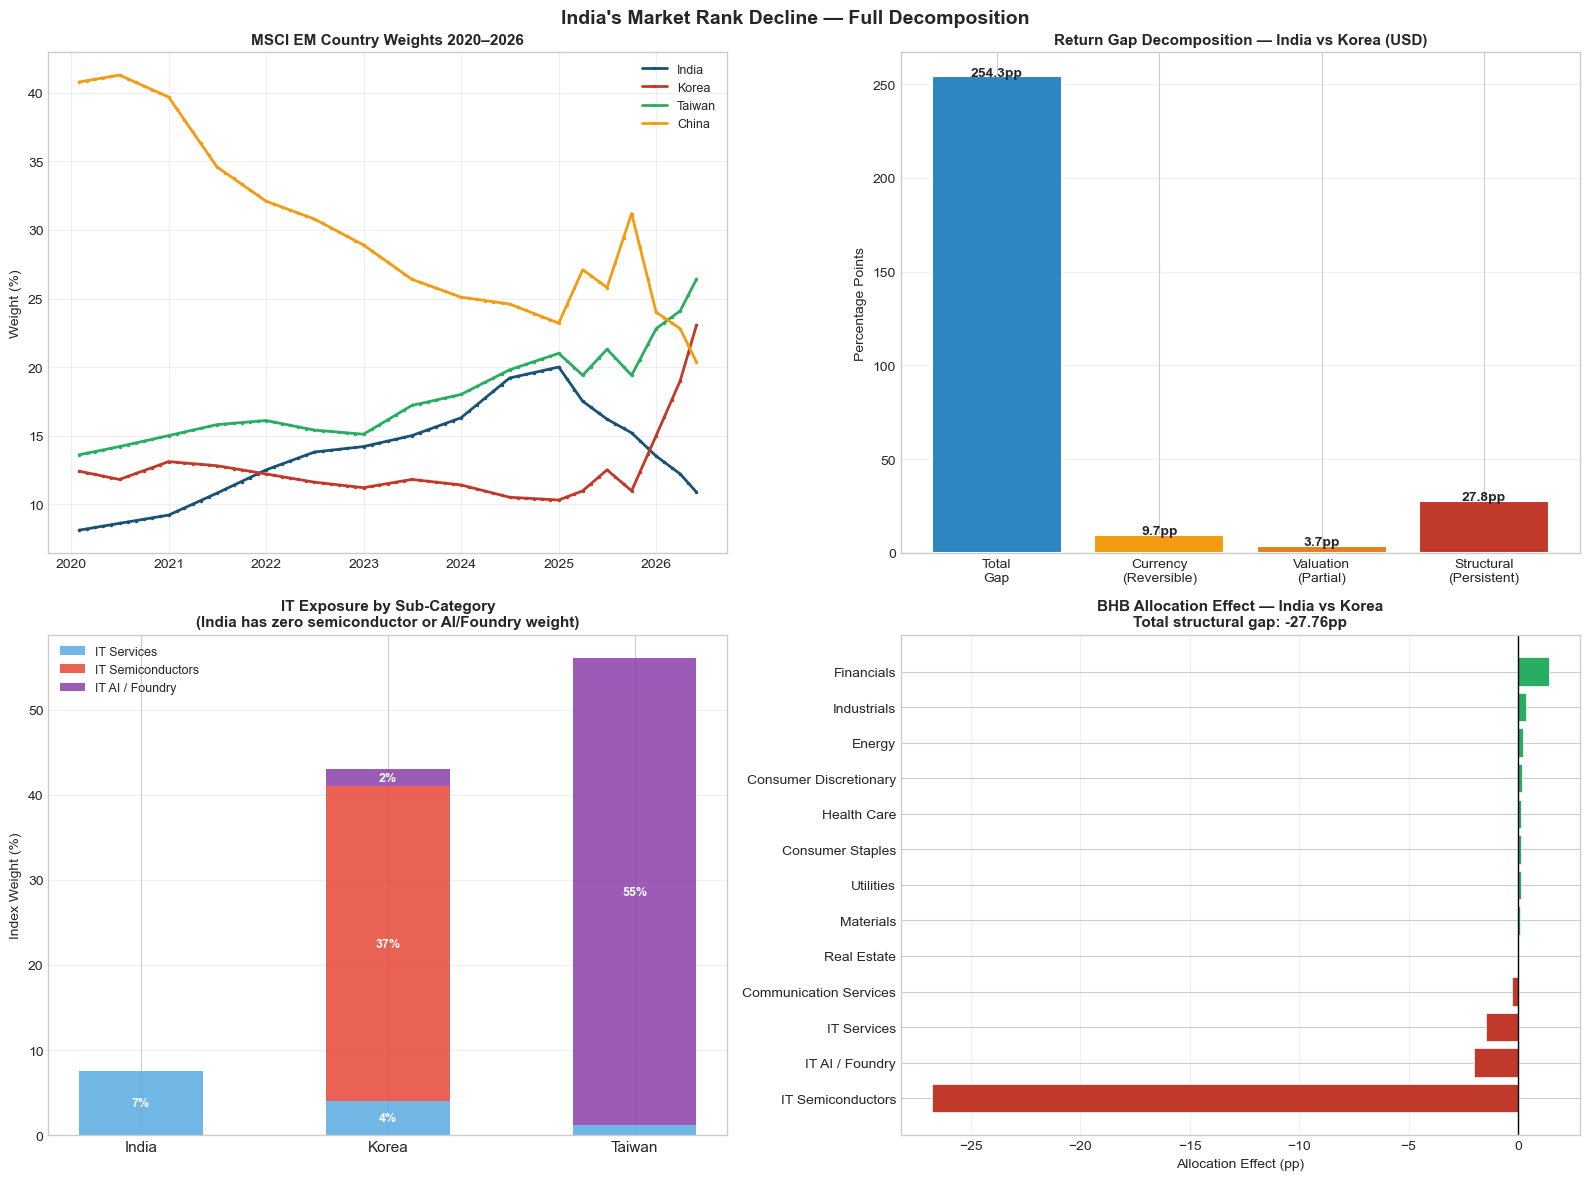

Chart saved.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("India's Market Rank Decline — Full Decomposition",
             fontsize=14, fontweight='bold')

# Panel 1: MSCI EM weight evolution
ax1 = axes[0, 0]
for country in ['India', 'Korea', 'Taiwan', 'China']:
    ax1.plot(weights_df.index, weights_df[country].astype(float),
             color=COLORS.get(country, '#7f8c8d'),
             linewidth=2, label=country, marker='.', markersize=3)
ax1.set_title("MSCI EM Country Weights 2020–2026", fontsize=11, fontweight='bold')
ax1.set_ylabel("Weight (%)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Return gap waterfall
ax2 = axes[0, 1]
buckets    = ['Total\nGap', 'Currency\n(Reversible)',
              'Valuation\n(Partial)', 'Structural\n(Persistent)']
values     = [abs(total_gap_korea), abs(currency_effect),
              abs(pe_effect),
              abs(refined_attr_df['effect_korea'].sum())]
bar_colors = ['#2e86c1', '#f39c12', '#e67e22', '#c0392b']
bars = ax2.bar(buckets, values, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.1f}pp', ha='center', fontsize=10, fontweight='bold')
ax2.set_title("Return Gap Decomposition — India vs Korea (USD)",
              fontsize=11, fontweight='bold')
ax2.set_ylabel("Percentage Points")
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: IT exposure breakdown - the structural story
ax3 = axes[1, 0]
countries  = ['India', 'Korea', 'Taiwan']
it_types   = ['IT Services', 'IT Semiconductors', 'IT AI / Foundry']
it_colors  = ['#5dade2', '#e74c3c', '#8e44ad']
x          = np.arange(len(countries))
width      = 0.5
bottom     = np.zeros(len(countries))

for it_type, color in zip(it_types, it_colors):
    vals = [sector_weights[c].get(it_type, 0) for c in countries]
    ax3.bar(x, vals, width, bottom=bottom, label=it_type, color=color, alpha=0.88)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 1.5:
            ax3.text(x[i], b + v / 2, f'{v:.0f}%',
                     ha='center', va='center', fontsize=9,
                     color='white', fontweight='bold')
    bottom += np.array(vals)

ax3.set_xticks(x)
ax3.set_xticklabels(countries, fontsize=11)
ax3.set_title("IT Exposure by Sub-Category\n(India has zero semiconductor or AI/Foundry weight)",
              fontsize=11, fontweight='bold')
ax3.set_ylabel("Index Weight (%)")
ax3.legend(fontsize=9, loc='upper left')
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: BHB allocation effect by sector
ax4 = axes[1, 1]
attr_sorted = refined_attr_df.sort_values('effect_korea')
bar_c = ['#c0392b' if v < 0 else '#27ae60' for v in attr_sorted['effect_korea']]
ax4.barh(attr_sorted['sector'], attr_sorted['effect_korea'],
         color=bar_c, edgecolor='white', linewidth=0.5)
ax4.axvline(0, color='black', linewidth=1)
ax4.set_title(
    f"BHB Allocation Effect — India vs Korea\n"
    f"Total structural gap: {refined_attr_df['effect_korea'].sum():+.2f}pp",
    fontsize=11, fontweight='bold')
ax4.set_xlabel("Allocation Effect (pp)")
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('phase_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 8. What's Reversible, What Isn't?

Bringing all three analyses together to answer the core research question.

In [11]:
print("=" * 65)
print("FINAL SYNTHESIS")
print("=" * 65)

macro_total    = currency_effect + pe_effect
macro_share    = abs(macro_total)    / abs(total_gap_korea) * 100
structural_share = abs(structural_residual_korea) / abs(total_gap_korea) * 100

print(f"""
RESEARCH QUESTION:
Is India's loss of equity market rank a temporary macro shock
or a structural story?

── SQ1: PASSIVE vs ACTIVE FLOWS ──
Total FII outflow (Jan 2025 → May 2026):  ${abs(total_fii):,.0f}M
Passive / mechanical:                      ${abs(total_passive):,.0f}M  ({abs(total_passive/total_fii)*100:.0f}%)
Active / discretionary:                    ${abs(total_active):,.0f}M   ({abs(total_active/total_fii)*100:.0f}%)

66% of India's $41.6B FII outflow was mechanically forced by MSCI
weight reduction — not an active call on India fundamentals.
The remaining 34% was discretionary selling, concentrated in H2 2025
and early 2026 as the Korea/Taiwan AI rally made the return gap
impossible to ignore.

Note: A Granger test (lag 3, p=0.0148) suggests flows may have
preceded weight changes, but both series are non-stationary and
the result does not survive multiple-comparison correction.
Treat as exploratory only — the passive/active split above is
the robust SQ1 finding.

── SQ2: STRUCTURAL vs MACRO ──
Total return gap vs Korea (USD):  {total_gap_korea:.1f}pp

  Bucket 1 — Currency (INR depreciation):   {currency_effect:.1f}pp  → REVERSIBLE
  Bucket 2 — Valuation re-rating (P/E):     {pe_effect:.1f}pp  → PARTIALLY REVERSIBLE
  Bucket 3 — Structural residual:           {structural_residual_korea:.1f}pp  → STRUCTURAL

  Macro combined:  {macro_total:.1f}pp  ({macro_share:.0f}% of gap)
  Structural:      {structural_residual_korea:.1f}pp  ({structural_share:.0f}% of gap)

── BHB SECTOR ATTRIBUTION — what drives the structural gap ──

  IT Services gap:       {refined_attr_df[refined_attr_df['sector']=='IT Services']['effect_korea'].values[0]:+.2f}pp   (India overweight in a −42% sector)
  IT Semiconductors gap: {refined_attr_df[refined_attr_df['sector']=='IT Semiconductors']['effect_korea'].values[0]:+.2f}pp  (India 0% vs Korea 37%) ← dominant
  IT AI / Foundry gap:   {refined_attr_df[refined_attr_df['sector']=='IT AI / Foundry']['effect_korea'].values[0]:+.2f}pp   (India 0% vs Korea 2%)

  BHB weight allocation effect:        {refined_attr_df['effect_korea'].sum():.1f}pp
  Within-sector return difference:     {structural_residual_korea - refined_attr_df['effect_korea'].sum():.1f}pp
  (India IT Services returned −42% vs Korea IT Semiconductors +72% — same structural root cause)

── CONCLUSION ──
  Structural component = {structural_share:.0f}% of total gap  → DOMINANT
  Macro component      = {macro_share:.0f}% of total gap   → MINOR

  India's rank decline is primarily structural, not a macro shock.
  Full INR recovery and P/E normalisation would close only {macro_share:.0f}% of the gap.
  The remaining {structural_share:.0f}% persists until Indian companies appear
  in the global semiconductor supply chain with meaningful index weight.

  The gap is not a temporary anomaly — it is a structural baseline
  that will reassert in every technology cycle.
""")

print("⚠️  Note: FII flows and MSCI weights are approximate.")
print("    Price returns (Cell 5) and P/E are from primary sources.")
print("    Update FII and MSCI data from NSDL and msci.com before publishing.")

FINAL SYNTHESIS

RESEARCH QUESTION:
Is India's loss of equity market rank a temporary macro shock
or a structural story?

── SQ1: PASSIVE vs ACTIVE FLOWS ──
Total FII outflow (Jan 2025 → May 2026):  $41,620M
Passive / mechanical:                      $27,390M  (66%)
Active / discretionary:                    $14,230M   (34%)

66% of India's $41.6B FII outflow was mechanically forced by MSCI
weight reduction — not an active call on India fundamentals.
The remaining 34% was discretionary selling, concentrated in H2 2025
and early 2026 as the Korea/Taiwan AI rally made the return gap
impossible to ignore.

Note: A Granger test (lag 3, p=0.0148) suggests flows may have
preceded weight changes, but both series are non-stationary and
the result does not survive multiple-comparison correction.
Treat as exploratory only — the passive/active split above is
the robust SQ1 finding.

── SQ2: STRUCTURAL vs MACRO ──
Total return gap vs Korea (USD):  -254.3pp

  Bucket 1 — Currency (INR depreciation)

## 9. Limitations & Concluding Observations

### Independence Assumption

The three-bucket decomposition - currency, valuation re-rating, and sector 
composition - treats each effect as analytically independent. This is a standard 
simplification in return attribution, but it understates the structural contribution 
in this specific case.

The currency and valuation effects are not purely macro in origin. They are 
partially endogenous to the structural gap itself.

**On currency:** Taiwan and South Korea run persistent current account surpluses 
driven almost entirely by semiconductor and advanced hardware exports, revenues 
denominated in USD that continuously bid up the TWD and KRW. India's current 
account deficit, and the resulting structural pressure on the INR, is partly a 
reflection of the absence of an equivalent high-value export base. Treating INR 
depreciation as a reversible macro variable therefore overstates how easily that 
bucket closes.

**On valuation:** A compression in India's index P/E from 23.1x to 18.0x reads 
as sentiment-driven and potentially reversible. However, if institutional allocators 
are systematically pricing in India's absence from the AI supply chain, knowing 
that every major tech cycle mechanically redirects passive flows toward 
semiconductor-heavy indices, then the re-rating is at least partially structural. 
A market that correctly prices a structural gap is not mis-valued; it is fairly valued.

### Implication for the Structural Estimate

The BHB sector attribution estimates a structural drag of −24.7pp against Korea. 
This should be treated as a lower bound. Adjusting for the endogeneity of the 
currency and valuation effects, the true structural contribution to India's equity 
market rank decline is likely materially larger.

### Forward Outlook

The macro factors, rupee depreciation and valuation compression, will partially 
normalise over time. They have before, and the domestic growth story remains intact. 
But normalisation of macro conditions does not close the structural gap. In each 
subsequent AI or semiconductor cycle, passive capital will mechanically rotate 
toward index-heavy semiconductor markets, and India, absent meaningful weight in 
that supply chain, will be a systematic loser of those flows.

India's path to a durable recovery in equity market rank runs through corporate 
and policy developments, not macroeconomic stabilisation alone: domestic 
semiconductor fabrication capacity, the emergence of index-eligible AI supply 
chain companies, and a gradual shift in MSCI India's sector composition away from 
its current financials and services concentration.

Until that happens, the gap identified in this study is not an anomaly to be 
corrected by the next rate cycle. It is a baseline.